In [22]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from flonacomldft.utils.io_utils import (load_pickle_file,
    get_project_path,
)
from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.plots import set_plot_sequential_data 

from flonacomldft.utils.diagnostics import R_hat

In [24]:
idx = 3209454

# Load the data
PROJECT_PATH = get_project_path()
SIMULATIONS_DATA_PATH = PROJECT_PATH+"/5-multimodal-mlp"
CVS_DATA_PATH = PROJECT_PATH+"/cvs_temporal"

In [25]:
ab_flowmm_mlp = {}
cvs_mlp = {}

for i in range(6):

    ab_flowmm_mlp[i] = load_pickle_file("results_multimodal_sampling_mixture_{:d}{:d}/checkpoint_NA_3000.pkl".format(
        idx, i), path=SIMULATIONS_DATA_PATH)
    cvs_mlp[i] = load_pickle_file("cvs_slices_{:d}{:d}_3000.pkl".format(
        idx, i), path=CVS_DATA_PATH)

In [26]:
labels_sims = {}

for i, j, k in zip(range(6), [5, 15, 30, 5, 15, 30], [1000, 1000, 1000, 1500, 1500, 1500]):
    labels_sims[i] = 'slice: {:d} mlp_init: {:d}'.format(j, k)

print(labels_sims)

{0: 'slice: 5 mlp_init: 1000', 1: 'slice: 15 mlp_init: 1000', 2: 'slice: 30 mlp_init: 1000', 3: 'slice: 5 mlp_init: 1500', 4: 'slice: 15 mlp_init: 1500', 5: 'slice: 30 mlp_init: 1500'}


# $\hat{R}$ calculations

In [27]:
us_cvs = {}

for i in range(6):
    us_cvs[i] = torch.cat((cvs_mlp[i], ab_flowmm_mlp[i]['us'].reshape(-1, 20, 1)), dim=2)

In [28]:
rhat = {}

for i in range(6):
    rhat[i] = R_hat(us_cvs[i].detach().numpy().transpose(1, 0, 2), labels=['C', 'R', 'U'])

In [29]:
time_mcmc = {}
for i in range(6):
    time_list = ab_flowmm_mlp[i]['time_mcmc']
    time_min = min(time_list)
    final_time = [t-time_min for t in time_list]
    time_mcmc[i]= np.array(final_time)/3600

In [30]:
time_mcmc

{0: array([0.00000000e+00, 5.36372887e-03, 1.24330947e-02, ...,
        1.99237734e+01, 1.99293700e+01, 1.99350934e+01]),
 1: array([0.00000000e+00, 6.42779344e-03, 1.23594749e-02, ...,
        1.88300204e+01, 1.88363357e+01, 1.88407110e+01]),
 2: array([0.00000000e+00, 6.93877876e-03, 1.19618369e-02, ...,
        1.90013545e+01, 1.90068172e+01, 1.90126728e+01]),
 3: array([0.00000000e+00, 5.16774933e-03, 1.18585504e-02, ...,
        1.90968750e+01, 1.91020488e+01, 1.91071829e+01]),
 4: array([0.00000000e+00, 5.97417348e-03, 1.11916980e-02, ...,
        1.73364259e+01, 1.73423501e+01, 1.73480545e+01]),
 5: array([0.00000000e+00, 5.21918403e-03, 1.09087996e-02, ...,
        1.68537746e+01, 1.68585008e+01, 1.68626042e+01])}

(array([[1.36845875, 1.19984603, 1.18615841],
       [1.21508493, 1.15801453, 1.13542474],
       [1.18854204, 1.15303069, 1.07540728],
       [1.18279051, 1.1410648 , 1.06903853],
       [1.19073593, 1.14791934, 1.07646092],
       [1.17137982, 1.18126811, 1.07073944],
       [1.15968975, 1.20009795, 1.05374001],
       [1.17974391, 1.21215614, 1.05017656],
       [1.16567181, 1.19923005, 1.05162613],
       [1.14386684, 1.18807195, 1.05528929]]), array([ 290,  580,  870, 1160, 1450, 1740, 2030, 2320, 2610, 2901]), ['C', 'R', 'U'])
(array([[1.24484674, 1.20337068, 1.20128224],
       [1.22146737, 1.18841409, 1.17444264],
       [1.13050137, 1.17111889, 1.08986807],
       [1.10111689, 1.17187509, 1.09696902],
       [1.08584574, 1.17720275, 1.09964004],
       [1.0859604 , 1.17549914, 1.07486062],
       [1.08065958, 1.15673809, 1.07079909],
       [1.08120956, 1.16054664, 1.07515545],
       [1.07955007, 1.16432236, 1.07450668],
       [1.07832493, 1.15659275, 1.06459817]]), array([ 

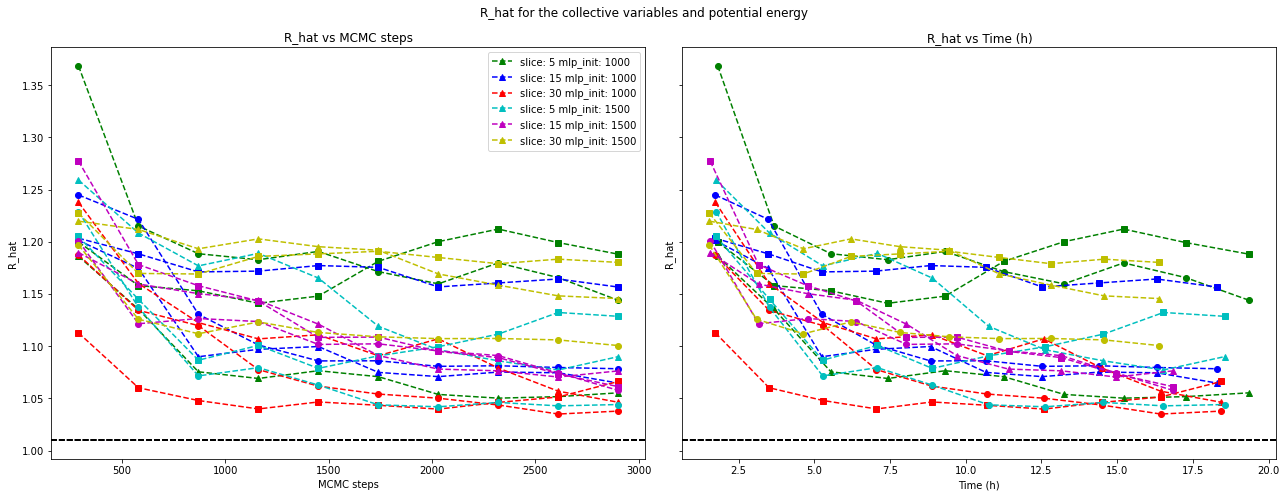

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
markers = ['o', 's', '^']
colors = ['g', 'b', 'r', 'c', 'm', 'y']

for i in range(6):
    print(rhat[i])
    for k in range(3):
        ax[0].plot( rhat[i][1], rhat[i][0][:, k], '--', marker=markers[k], color=colors[i], label="{:s}".format(labels_sims[i]))
        ax[1].plot( time_mcmc[i][rhat[i][1]], rhat[i][0][:, k], '--', marker=markers[k], color=colors[i], label="{:s}".format(labels_sims[i]))
 
    ax[0].axhline(1.01, color='k', linestyle='--')
    ax[0].set_xlabel("MCMC steps")
    ax[0].set_ylabel("R_hat")
    ax[0].set_title("R_hat vs MCMC steps")

    ax[1].axhline(1.01, color='k', linestyle='--')
    ax[1].set_xlabel("Time (h)")
    ax[1].set_ylabel("R_hat")
    ax[1].set_title("R_hat vs Time (h)")

handles, labels = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax[0].legend(by_label.values(), by_label.keys())

fig.suptitle("R_hat for the collective variables and potential energy")
plt.tight_layout()

# Plot acceptances

In [32]:
accs = {}

for i in range(6):
    accs[i] = ab_flowmm_mlp[i]['accs'].float().mean(dim=1)    

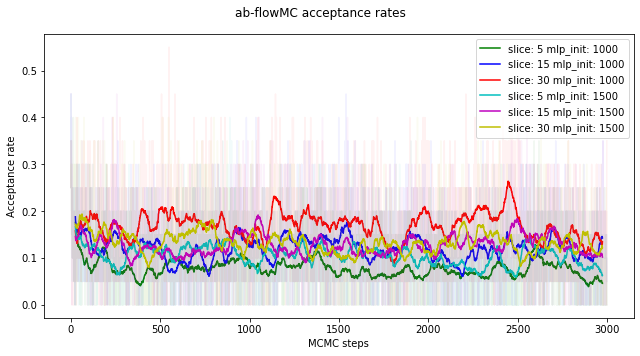

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5), sharey=True)

for i in range(6):
    set_plot_sequential_data(accs[i], ax=ax, color=colors[i], window_size=50, alpha=0.05, label="{:s}".format(labels_sims[i]))
    ax.set_xlabel("MCMC steps")
    ax.set_ylabel("Acceptance rate")
    ax.legend()
    #ax.set_title("Isomer {:d}".format(i))

fig.suptitle("ab-flowMC acceptance rates")
plt.tight_layout()

# Energy histograms

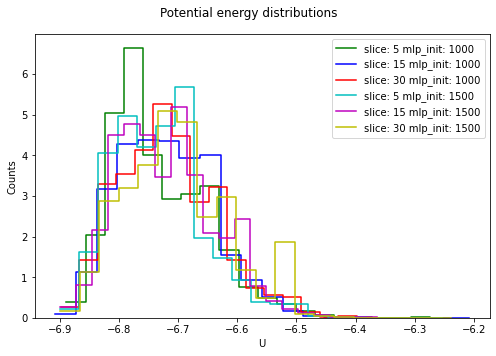

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for i in range(6):

    sns.histplot(us_cvs[i][:, :, 2].flatten(),
    bins=20,
    fill=False,
    color=colors[i],
    stat="density",
    element="step",
    ax=ax,
    label="{:s}".format(labels_sims[i]))
    j += 1

    ax.set_xlabel("U")
    ax.set_ylabel("Counts")
    ax.legend()

fig.suptitle("Potential energy distributions")
plt.tight_layout()

# Jumps between isomers

In [35]:
isomers = {}

for i in range(6):
    isomers[i] = ab_flowmm_mlp[i]['isomers']

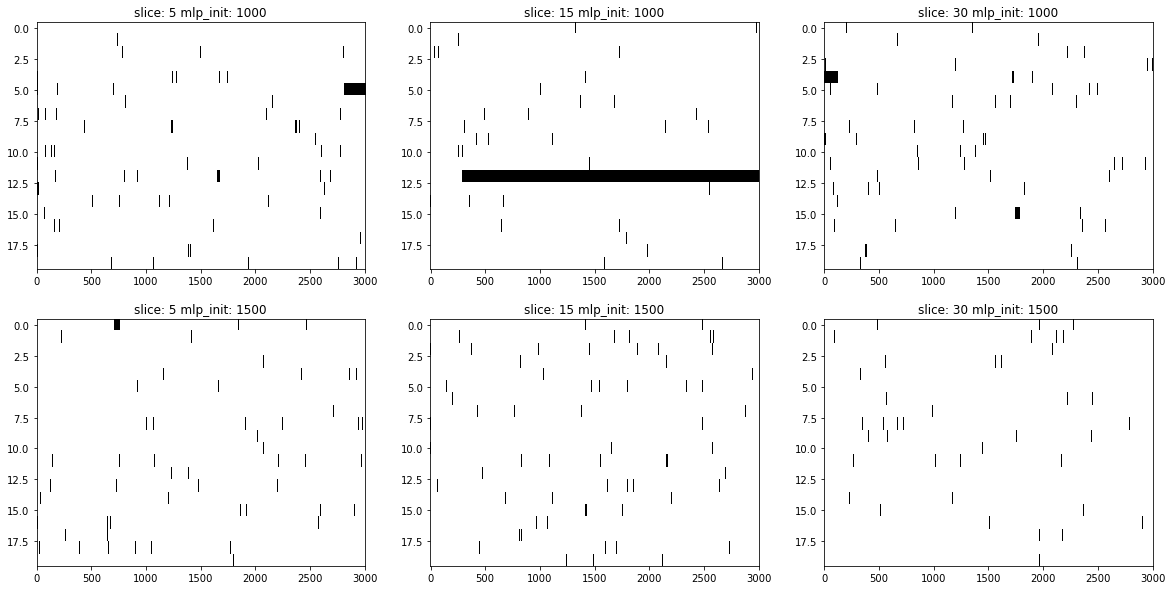

In [36]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))

axs = axs.ravel()

for i in range(6):

    axs[i].imshow(isomers[i].T, aspect='auto', cmap='gray_r', interpolation='none')
    axs[i].set_title("{:s}".format(labels_sims[i]))

# Free energy

# MLP comparison with predictions